# HW02_Q1andQ4

# Q1

Text(0.5, 1.0, 'Auto MPG dataset')

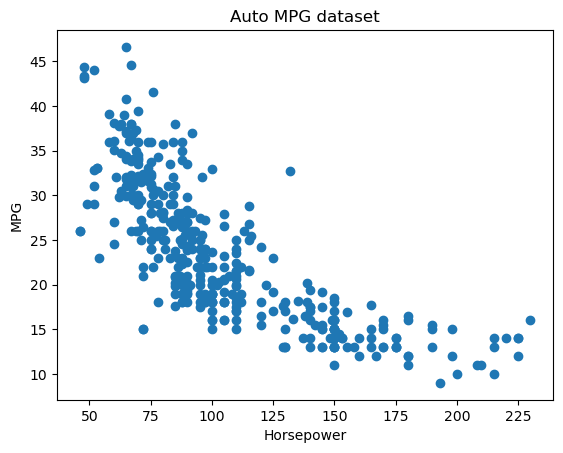

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
# load data from seaborn library
Auto = sns.load_dataset("mpg").dropna()
# plot x vs y
plt.scatter(Auto['horsepower'], Auto['mpg'])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Auto MPG dataset")

In [2]:
def getPoly(x, degree):
    '''
    # input: feature vector x and polynomial degree
    # output: feature matrix of orthogonal polynomial features
    '''
    
    x = np.array(x)
    # add polynomial degree
    X = [x**i for i in range(degree+1)]
    X = np.array(X).T
    
    # perform QR decomposition
    q, r = np.linalg.qr(X)
    d = np.diag(r)
    q *= np.sign(d)
    
    q[:, 0] = np.ones(len(x))
    
    # return the orthogonal polynomial features
    return q

## Leave-One-Out Cross-Validation (LOOCV)

In [3]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import LeaveOneOut

def LOOCV(X, y):
    
    e = 0.0
    loo = LeaveOneOut()
    
    # perform LOOCV 
    for train, test in loo.split(X):
        # extract data points
        X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
        # fit OLS model
        model = sm.OLS(y_train, X_train).fit()
        # perform prediction
        y_pred = model.predict(X_test)
        # store MSE
        e += ((y_test - y_pred)**2)[0]
    
    # retuen avg MSE
    return e / len(y)

### Polynomial regression (degree 1–10) on Auto MPG with LOOCV test error

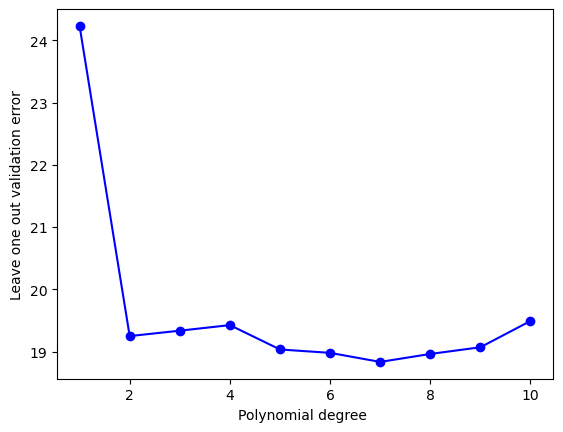

In [4]:
deg = 10
x = Auto['horsepower'].values
y = Auto["mpg"].values
cv1 = np.zeros(deg)

for i in range(1, deg+1):
    # generate the polynomial feature matrix
    Xp = getPoly(x, i)
    cv1[i-1] = LOOCV(Xp, y)
    
cv1 = np.array(cv1)

plt.plot(np.arange(1, deg+1), cv1, marker='o', color="blue")
plt.xticks(range(2,deg+1, 2))

plt.xlabel("Polynomial degree ")
plt.ylabel("Leave one out validation error")
plt.show()

In [5]:
pd.DataFrame(cv1, index=np.arange(1, len(cv1)+1))

,0
1,24.231514
2,19.248213
3,19.334984
4,19.424430
5,19.033214
6,18.978644
7,18.833045
8,18.961151
9,19.068630
10,19.490932


### Polynomial regression (degree 1–20) on Auto MPG with LOOCV test error

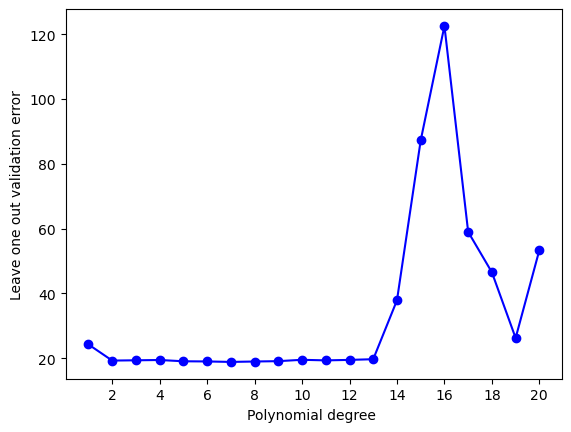

In [6]:
deg = 20
x = Auto['horsepower'].values
y = Auto["mpg"].values
cv2 = np.zeros(deg)

for i in range(1, deg+1):
    # generate the polynomial feature matrix
    Xp = getPoly(x, i)
    cv2[i-1] = LOOCV(Xp, y)
    
cv2 = np.array(cv2)

plt.plot(np.arange(1, deg+1), cv2, marker='o', color="blue")
plt.xticks(range(2,deg+1, 2))

plt.xlabel("Polynomial degree ")
plt.ylabel("Leave one out validation error")
plt.show()

In [7]:
pd.DataFrame(cv2, index=np.arange(1, len(cv2)+1))

,0
1,24.231514
2,19.248213
3,19.334984
4,19.424430
5,19.033214
6,18.978644
7,18.833045
8,18.961151
9,19.068630
10,19.490932


Here, we fit polynomials of degrees 1 to 20 and use LOOCV to evaluate the test error. We can see that all of the higher-degree polynomial models (degrees 2–13) perform better than the linear model. As observed above, the lowest error occurs at degree 7, although the difference between the higher-order polynomials (degrees 2–13) is small. However, at polynomial degree 14, the test error increases significantly, indicating of overfitting. Therefore, we conclude that a degree 7 polynomial provides the best fit for the data.

### Fit the OLS model using polynomial degree 7

In [8]:
x = Auto['horsepower'].values
Xp = getPoly(x, 7)
y = Auto["mpg"].values
model = sm.OLS(y, Xp).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     129.5
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           5.38e-97
Time:                        22:55:14   Log-Likelihood:                -1123.6
No. Observations:                 392   AIC:                             2263.
Df Residuals:                     384   BIC:                             2295.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.4459      0.217    108.058      0.000      23.019      23.873
x1          -120.1377      4.296    -27.966      0.000    -128.584    -111.691
x2            44.0895      4.296     10.263      0.000      35.643      52.536
x3            -3.9488      4.296     -0.919      0.359     -12.395       4.498
x4            -5.1878      4.296     -1.208      0.228     -13.634       3.259
x5            13.2722      4.296      3.089      0.002       4.826      21.719
x6            -8.5462      4.296     -1.989      0.047     -16.993      -0.100
x7             7.9806      4.296      1.858      0.064      -0.466      16.427
==============================================================================
Omnibus:                       24.565   Durbin-Watson:                   1.130
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.277
Skew:                           0.352   Prob(JB):                     1.99e-11
Kurtosis:                       4.588   Cond. No.                         19.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Using a 7-degree polynomial, the model achieved an $R^2$ of 0.702 and an adjusted $R^2$ of 0.69.

## KFold Cross Validation

In [9]:
import statsmodels.api as sm
from sklearn.model_selection import KFold

def KFoldCV(X, y, k=5):    
    e = 0.0
    # split the dataset into k-fold
    kf = KFold(n_splits=k, shuffle=True)
    
    # fit the model over each fold
    for train, test in kf.split(X):
        # extract data
        X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
        # fit OLS model
        model = sm.OLS(y_train, X_train).fit()
        # perform prediction 
        y_pred = model.predict(X_test)
        # store MSE
        e += np.mean((y_test - y_pred)**2)
    # return average MSE    
    return e / k

### 10-fold cross-validation using polynomial degrees 1–12 on Auto MPG

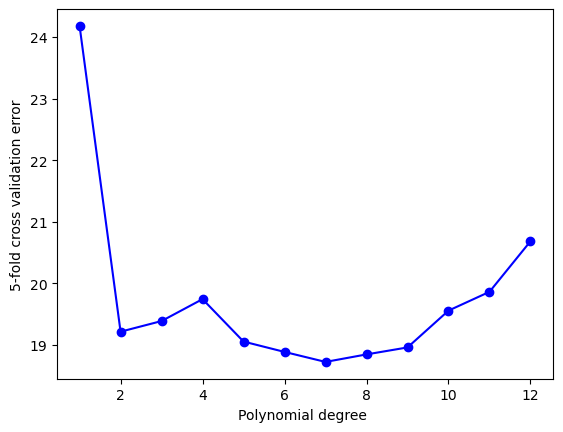

In [10]:
k = 10
deg = 12

x = Auto['horsepower'].values
y = Auto["mpg"].values
cv3 = np.zeros(deg)

for i in range(1, deg+1):
    Xp = getPoly(x, i)
    cv3[i-1] = KFoldCV(Xp, y, k)
    
cv3 = np.array(cv3)

plt.plot(np.arange(1, deg+1), cv3, marker='o', color="blue")
plt.xticks(range(2,deg+1, 2))

plt.xlabel("Polynomial degree ")
plt.ylabel("5-fold cross validation error")
plt.show()

### 5-fold cross-validation using polynomial degrees 1–12 on Auto MPG

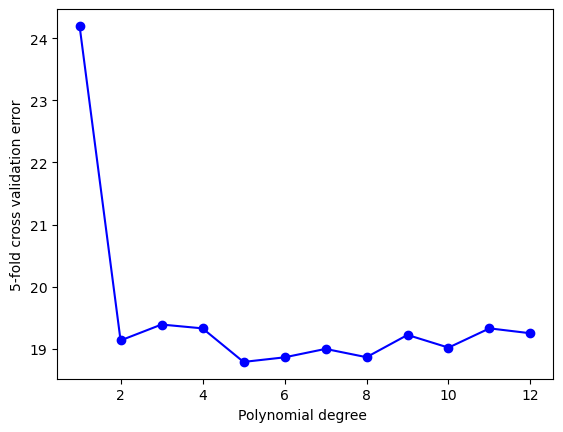

In [11]:
k = 5
deg = 12

x = Auto['horsepower'].values
y = Auto["mpg"].values
cv4 = np.zeros(deg)

for i in range(1, deg+1):
    Xp = getPoly(x, i)
    cv4[i-1] = KFoldCV(Xp, y, k)
    
cv4 = np.array(cv4)

plt.plot(np.arange(1, deg+1), cv4, marker='o', color="blue")
plt.xticks(range(2,deg+1, 2))

plt.xlabel("Polynomial degree ")
plt.ylabel("5-fold cross validation error")
plt.show()

In [12]:
pd.DataFrame(cv4, index=np.arange(1, len(cv4)+1))

,0
1,24.198535
2,19.132641
3,19.388858
4,19.326937
5,18.786559
6,18.860333
7,18.996226
8,18.862747
9,19.221348
10,19.016815


Based on the 5-fold cross-validation for polynomial degrees 1 to 12, we can see that all higher-order polynomials produce a similar MSE, and all of them outperform the linear model.

# Q4

In [13]:
import numpy as np
import numpy.random as npr
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


def getX(x, degree):
    '''
    # input: feature vector x and polynomial degree
    # output: feature matrix of orthogonal polynomial features
    '''
    x = np.array(x)
    # add polynomial degree
    X = [x**i for i in range(degree+1)]
    X = np.array(X).T
    
    # perform QR decomposition
    q, r = np.linalg.qr(X)
    d = np.diag(r)
    q *= np.sign(d)
    
    q[:, 0] = np.ones(len(x))
    
    # return the orthogonal polynomial features
    return q


def getMSE(y_true, y_pred):
    e = y_true - y_pred
    # compute MSE
    mse = e.T@e / len(e)
    return mse

def errorSim(n, mu, s, deg, R1, R2):
    
    x = npr.uniform(0, 3, n) # sample from uniform
    x = np.sort(x)
    f = 10 + np.sin(2*x) # true relationship
    # generate the polynomial feature matrix
    X = getX(x, deg) 
    
    training_error = []
    prediction_MSE = []
    
    # loop over traning data simulation replicates
    for i in range(R1):
        # add noise
        y_train = f + npr.normal(mu, s, n)
        # fit OLS model
        model = sm.OLS(y_train, X).fit()
        # perform prediction
        y_pred = model.predict(X)
        training_error.append(getMSE(y_train, y_pred))
        
        test_mse = []
        y_pred = model.predict(X)
        # loop over test data simulation replicates
        for j in range(R2):
            # add noise
            y_test = f + npr.normal(mu, s, n)
            # compute MSE and store
            test_mse.append(getMSE(y_test, y_pred))
        prediction_MSE.append(np.mean(test_mse))
    
    avg_train = np.mean(training_error)
    avg_pred = np.mean(prediction_MSE)
    # compute avg optimism
    avg_optimism = avg_pred - avg_train
    #avg_optimism = avg_train - avg_pred 

    return avg_optimism, avg_pred


op_0p5 = []
op_1 = []
op_2 = []

ap_0p5 = []
ap_1 = []
ap_2 = []

# compute optimism for polynomial degrees 1–10 with noise sd = 0.5
for i in range(10):
    n = 50 # num of sample
    mu = 0 # mean of the normal distribution
    s = 0.5 # sd of the normal distribution
    deg = i # polynomial degrees
    R1 = 1000 # traning replicates 
    R2 = 1000 # test replicates
    avg_optim, avg_pred = errorSim(n, mu, s, deg, R1, R2)
    op_0p5.append(avg_optim)
    ap_0p5.append(avg_pred)
    
# compute optimism for polynomial degrees 1–10 with noise sd = 1.0
for i in range(10):
    n = 50 # num of sample
    mu = 0 # mean of the normal distribution
    s = 1 # sd of the normal distribution
    deg = i # polynomial degrees
    R1 = 1000 # traning replicates 
    R2 = 1000 # test replicates
    avg_optim, avg_pred = errorSim(n, mu, s, deg, R1, R2)
    op_1.append(avg_optim)   
    ap_1.append(avg_pred)

    
# compute optimism for polynomial degrees 1–10 with noise sd = 2.0
for i in range(10):
    n = 50 # num of sample
    mu = 0 # mean of the normal distribution
    s = 2 # sd of the normal distribution
    deg = i # polynomial degrees
    R1 = 1000 # traning replicates 
    R2 = 1000 # test replicates
    avg_optim, avg_pred = errorSim(n, mu, s, deg, R1, R2)
    op_2.append(avg_optim)  
    ap_2.append(avg_pred)


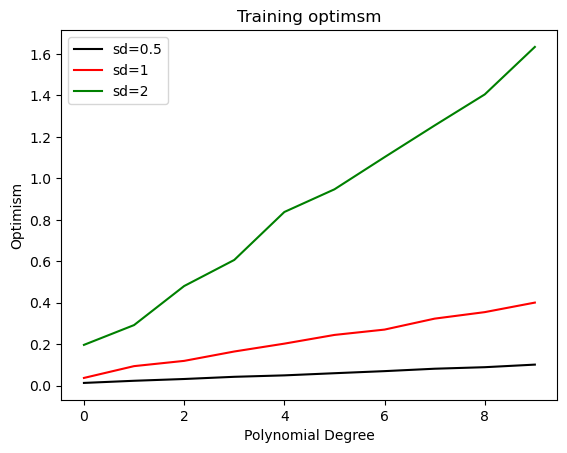

In [14]:
import numpy as np
import matplotlib.pyplot as plt

degree = np.arange(0, 10)
plt.plot(degree, op_0p5, color='black', label='sd=0.5')
plt.plot(degree, op_1,  color='red', label='sd=1')
plt.plot(degree, op_2,  color='green', label='sd=2')

plt.xlabel("Polynomial Degree")
plt.ylabel("Optimism")
plt.title("Training optimsm")

plt.legend()
plt.show()

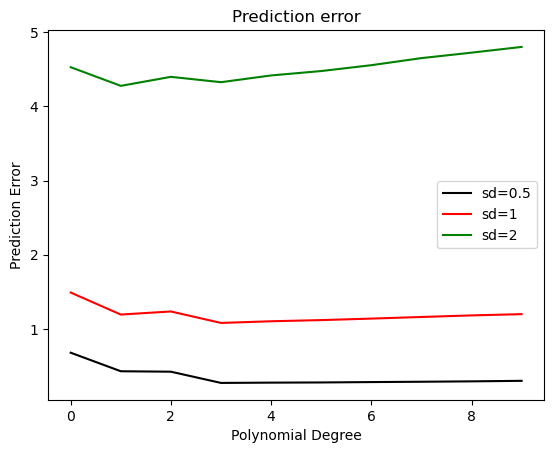

In [15]:
import numpy as np
import matplotlib.pyplot as plt

degree = np.arange(0, 10)
plt.plot(degree, ap_0p5, color='black', label='sd=0.5')
plt.plot(degree, ap_1,  color='red', label='sd=1')
plt.plot(degree, ap_2,  color='green', label='sd=2')

plt.xlabel("Polynomial Degree")
plt.ylabel("Prediction Error")
plt.title("Prediction error")

plt.legend()
plt.show()

In this simulation, we explore prediction error, training error, and training error optimism. The first plot represents optimism vs. polynomial degree (1–10) across three different noise levels. From the figure, we can see that with a small error variance (SD=0.5), the optimism increases slowly with higher-order polynomial degrees. However, when we increase the standard deviation to SD=1, the optimism increases at a higher rate. Finally, for large error variances (SD=2), the optimism increases almost exponentially.

The second plot shows the polynomial degree on the x-axis and the prediction error on the y-axis. Here, we observe that a higher SD leads to a higher prediction error. For small error variances, higher-order polynomials do not significantly change the prediction error. However, the prediction error increases slightly for higher error variances and higher polynomial degrees.

In conclusion, both figures align with our expectations. Firstly, simpler models are more robust against random noise in the training data. As the polynomial degree increases, the training error decreases while the test error increases, causing optimism to rise, particularly at higher noise levels. Regarding prediction error, higher order polynomials lead to higher errors because the model begins overfitting to the training data.